In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Exercícios

In [19]:
def show_img(img1, img2, title1, title2):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 10))

  ax1.imshow(img1)
  ax1.set_title(title1)

  ax2.imshow(img2)
  ax2.set_title(title2)

  plt.tight_layout()
  plt.show()

### Inversão de imagens

A operação de inversão de imagens precisa de duas informações principais: a imagem que vai ser transformada e um código que diz como inverter.

Existem 3 modos de inversão, os quais serão determinados pelo `flipCode`:

* `0 (Inversão Vertical)` = gira a imagem de cabeça para baixo
* `1 (Inversão Horizontal)` = gira a imagem da esquerda para a direita
* `-1 (Inversão Ambos os lados)` = gira a imagem de cabeça para baixo e da esquerda para a direita ao mesmo tempo.

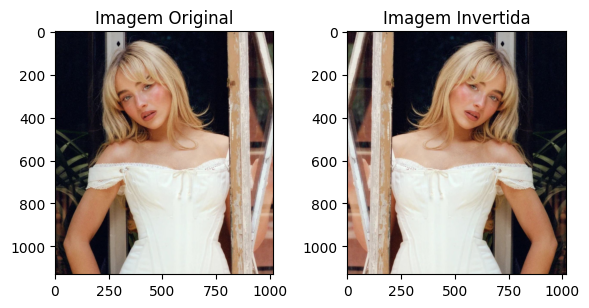

In [20]:
image = cv2.imread("/content/img/imagem1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#inversão no eixo horizontal (esquerda para direita)
imagem_invertida = cv2.flip(image, 1)

show_img(image, imagem_invertida, "Imagem Original", "Imagem Invertida")

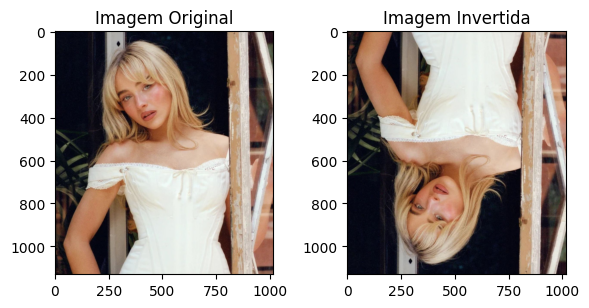

In [21]:
#inversão no eixo vertical
imagem_invertida = cv2.flip(image, 0)

show_img(image, imagem_invertida, "Imagem Original", "Imagem Invertida")

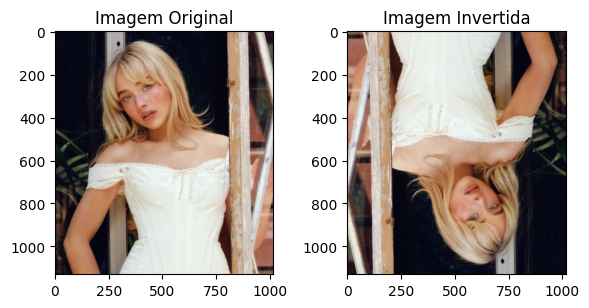

In [22]:
#as duas inversões juntas
imagem_invertida = cv2.flip(image, -1)

show_img(image, imagem_invertida, "Imagem Original", "Imagem Invertida")

### Translação de imagens

É o processo de deslocar uma imagem de uma posição para outra, movendo todos os seus pixels de forma horizontal (eixo X) ou vertical (eixo Y) sem alterar o tamanho ou forma original.

O OpenCV utiliza uma matriz afim que define o deslocamento nos eixos. E a função `cv2.warpAffine()` aplica essa matriz à imagem informada.

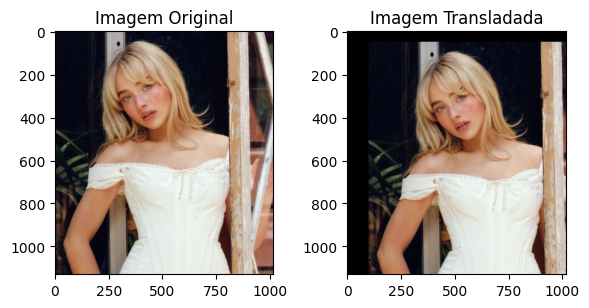

In [23]:
#matriz afim para deslocar 100 pixels em X e 50 em Y
M = np.float32([[1, 0, 100], [0, 1, 50]])

linhas, colunas = image.shape[:2]

#os argumentos são imagem original, matriz de transformação e o tamanho final da imagem
imagem_transladada = cv2.warpAffine(image, M, (colunas, linhas))

show_img(image, imagem_transladada, "Imagem Original", "Imagem Transladada")

### Rotação de imagens

É uma operação que consiste em **girar uma imagem em torno de um ponto específico** (geralmente o centro) **por um ângulo determinado**.

Em processamento de imagens a rotação ocorre a partir de um ângulo definido.

A biblioteca simplifica o processo de rotação usando duas funções, diferente da translação que consegue ser descrita diretamente por uma única matriz.

* `cv2.getRotationMatrix2d()` = calcula a matriz de transformação da rotação
* `cv2.warpAffine()` = aplica a matriz à imagem


ps: visto que a rotação depende de várias coisas: ângulo, centro de rotação e escala; é aplicada uma função específica para montar a matriz.

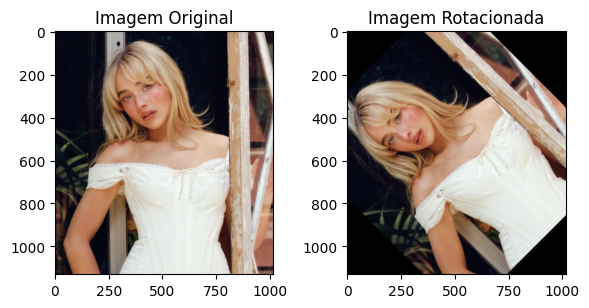

In [24]:
#pegando as dimensões da imagem
height, width = image.shape[:2]

#definindo o centro
center = (width // 2, height // 2)

#definindo o ângulo de rotação
angle = 45

#definindo o fator de escala
scale = 1.0       #no scaling

rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
rotated_image = cv2.warpAffine(image, rotation_matrix, (width, height))

show_img(image, rotated_image, "Imagem Original", "Imagem Rotacionada")

### Negativo de imagens

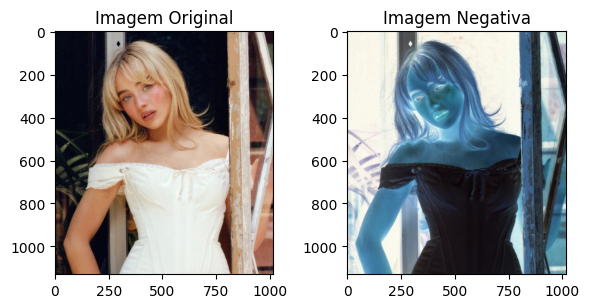

In [25]:
negativo = 255 - image

show_img(image, negativo, "Imagem Original", "Imagem Negativa")

### Referências

[Image Rotation and Translation using OpenCV
](https://opencv.org/image-rotation-and-translation-using-opencv/)